In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# List of your results files
files = {
    "Gemma-3n-E2B-it": "../../opera_log/chair_eval_results/google/gemma-3n-E2B-it/deco/metric.json",
    "Gemma-3-4b-it": "../../opera_log/chair_eval_results/google/gemma-3-4b-it/deco/metric.json",
    "Gemma-3n-E4B-it": "../../opera_log/chair_eval_results/google/gemma-3n-E4B-it/deco/metric.json",
    "Qwen2.5-VL-3B-it": "../../opera_log/chair_eval_results/Qwen/Qwen2.5-VL-3B-Instruct/deco/metric.json",
    "LLaVA-1.5": "../../opera_log/chair_eval_results/llava-hf/llava-1.5-7b-hf/deco/metric.json",
    
    # Add more model result files here
}

In [4]:
metrics = {}
# Extract overall_metrics
for model, path in files.items():
    with open(path, "r") as f:
        data = json.load(f)
    metrics[model] = data.get("overall_metrics", {})

# Convert to DataFrame for easy comparison
df = pd.DataFrame(metrics).T  # transpose to have models as rows

print(df.apply(lambda col: col.map(lambda x: f"{x*100:.2f}")))

                 CHAIRs CHAIRi Recall    Len
Gemma-3n-E2B-it   13.20   6.35  41.62  60.76
Gemma-3-4b-it      5.09   3.24  34.29  62.58
Gemma-3n-E4B-it   14.20   6.52  41.62  60.83
Qwen2.5-VL-3B-it  10.16   4.18  45.43  60.98
LLaVA-1.5         18.20   6.06  64.06  51.70


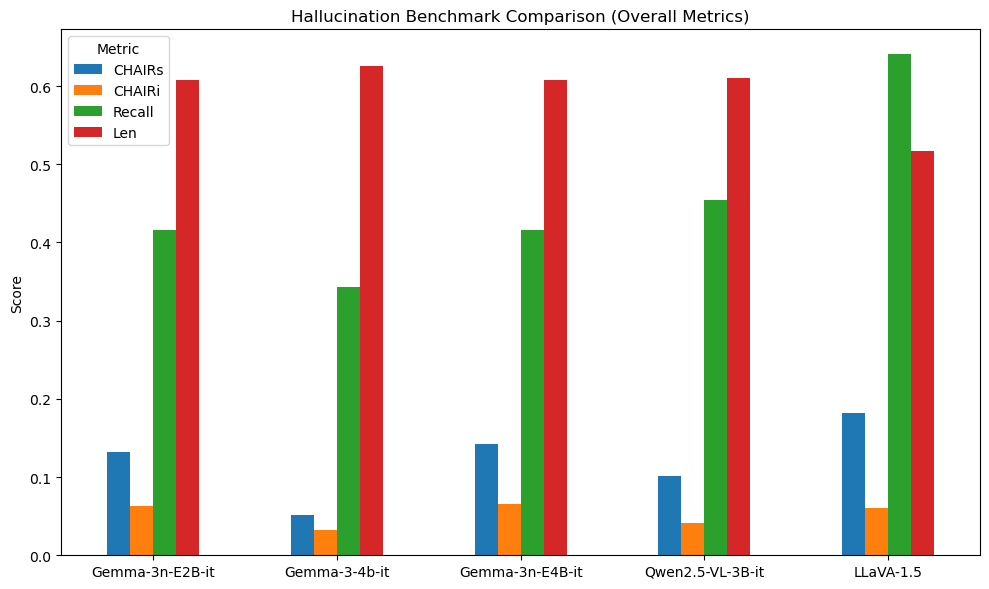

In [5]:
# Plot grouped bar chart
df.plot(kind="bar", figsize=(10,6))
plt.title("Hallucination Benchmark Comparison (Overall Metrics)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()